# <center> **ML-3. Обучение с учителем: классификация**

>**Задача классификации (classification)** — задача, в которой мы пытаемся предсказать класс объекта на основе признаков в наборе данных. То есть задача сводится к предсказанию целевого признака, который является **категориальным**.

Когда классов, которые мы хотим предсказать, только два, классификация называется **бинарной**. 

Когда классов, которые мы хотим предсказать, более двух, классификация называется **мультиклассовой (многоклассовой)**.

Что вообще означает «решить задачу классификации»? Это значит построить разделяющую поверхность в пространстве признаков, которая делит пространство на части, каждая из которых соответствует определённому классу. 

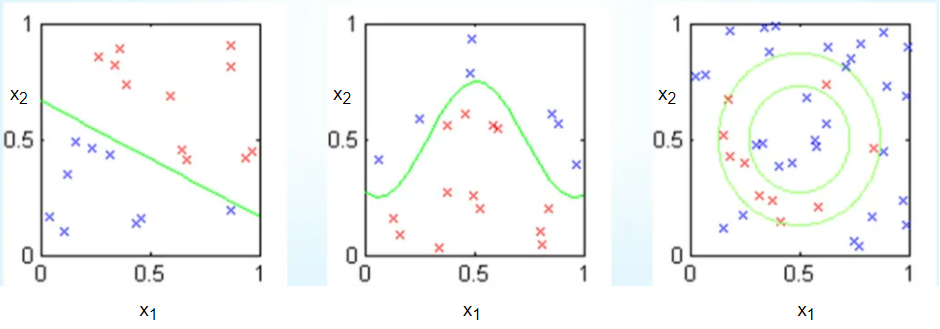

>Модели, которые решают задачу классификации, называются **классификаторами (classifier)**.

Если взять в качестве разделяющей поверхности некоторую плоскость (ровная поверхность на первом рисунке), то мы получаем модель **логистической регрессии**, которая тесно связана с рассмотренной нами ранее линейной регрессией.

Давайте для начала вспомним, как выглядит уравнение модели линейной регрессии в общем случае:
$$\hat{y}=w_0+w_1x_1+w_2x_2+\dots + w_mx_m=w_0+\sum _{j=1} ^{m} w_jx_j $$

В общем случае это уравнение гиперплоскости, которая стремится приблизить зависимость целевой переменной от  факторов.
* Когда фактор всего один, уравнение задаёт прямую:
$$\hat{y}=w_0+w_1x$$
* Когда факторов два, уравнение задаёт плоскость:
$$\hat{y}=w_0+w_1x_1+w_2x_2$$

>Переведём задачу классификации в задачу регрессии. Вместо предсказания класса будем предсказывать вероятность принадлежности к этому классу. 

Модель должна выдавать некоторую вероятность P, которая будет определять, принадлежит ли данный объект к классу 1: например, вероятность того, что письмо является спамом. При этом вероятность того, что письмо является обычным письмом (класс 0), определяется как Q = 1-P.  

Когда модель будет обучена на предсказание вероятности, мы зададим некоторый порог вероятности. Если предсказанная вероятность будет выше этого порога, мы определим объект к классу 1, а если ниже — к классу 0.

Например, стандартный порог равен 0.5. То есть если вероятность $P>0.5$, мы будем считать письмо спамом, а если $P \leq 0.5$ — обычным информативным письмом.

В итоге мы добьёмся того, что будем предсказывать не дискретный категориальный, а непрерывный числовой признак, который лежит в диапазоне [0, 1]. А это уже знакомая нам задача регрессии.

>Однако остался главный вопрос: как научить модель предсказывать вероятности, ведь они должны лежать строго в диапазоне от 0 до 1, а предсказания линейной регрессии лежат в диапазоне от $-\infty$ до $\infty$? 

**Тут-то мы и приходим к модели логистической регрессии — регрессии вероятностей.**

---

### <center> ОБЩЕЕ ПРЕДСТАВЛЕНИЕ О ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ

>**Логистическая регрессия (Logistic Regression)** — одна из простейших моделей для решения задачи классификации. Несмотря на простоту, модель входит в топ часто используемых алгоритмов классификации в Data Science.

В основе логистической регрессии лежит логистическая функция (logistic function) $\sigma(z)$ — отсюда и название модели. Однако более распространённое название этой функции — **сигмόида (sigmoid)**. Записывается она следующим образом:
$$\sigma(z)=\frac{1}{1+e^{-z}}$$

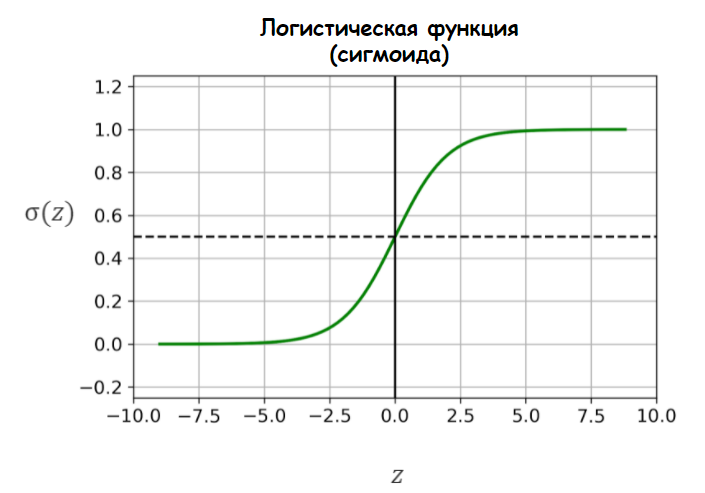

>У сигмоиды есть два очень важных для нас свойства:
* Значения сигмоиды $\sigma(z)$ лежат в диапазоне от 0 до 1 при любых значения аргумента z: какой бы z вы ни подставили, число меньше 0 или больше 1 вы не получите.
* Сигмоида выдаёт значения $\sigma(z)>0.5$ при её аргументе z>0, $\sigma(z)<0.5$ — при z<0 и $\sigma(z)=0.5$ — при z=0.

Это ведь и есть свойства вероятности! Выходом сигмоиды является число от 0 до 1, которое можно интерпретировать как вероятность принадлежности к классу 1. Её мы и пытаемся предсказать.

**Основная идея** модели логистической регрессии: возьмём модель линейной регрессии (обозначим её выход за z)
$$z=w_0+\sum _{j=1} ^m w_jx_j$$

и подставим выход модели z в функцию сигмоиды, чтобы получить искомые оценки вероятности (в математике принято писать оценочные величины с «шапкой» наверху, а истинные значения — без «шапки», это чистая формальность):
$$\hat{P}=\sigma(z)=\frac{1}{1+e^{-z}}=\frac{1}{1+e^{-w_0-\sum _{j=1} ^m w_jx_j}}= \frac{1}{1+e^{-\bar{w}\bar{x}}}$$

>**Примечание**. Далее в модуле мы будем называть оценки вероятности $\hat{P}$ просто вероятностью, но только для краткости. Это не значит, что эти оценки являются истинными вероятностями принадлежности к каждому из классов (их нельзя сосчитать, так как для этого нужна выборка бесконечного объёма). Если вы употребляете термин «вероятности» на собеседованиях, обязательно предварительно укажите, что вы подразумеваете оценку вероятности.

Обучать будем всё в совокупности, пытаясь получить наилучшую оценку вероятности $\hat{P}$. Если вероятность $\hat{P}>0.5$, относим объект к классу 1, а если $\hat{P} \leq 0.5$, относим объект к классу 0. 

Математически это записывается следующей формулой:
$$\hat{y}=I[\hat{P}]=
    \begin{cases}
        1, \hat{P}>0.5  \\
        0, \hat{P} \leq 0.5 
    \end{cases} $$

>**Примечание**. В данном выражении $I[\hat{P}]$ называется **индикаторной функцией**. Она возвращает 1, если её значение больше какого-то порога, и 0 — в противном случае. Математики часто записывают просто квадратные скобки, опуская символ I: $[\hat{P}]$.

Если мы обучим модель, то есть подберём  коэффициенты $w_0,w_1,\dots , w_m$ (как их найти, обсудим чуть позже) таким образом, что для объектов класса 1 модель линейной регрессии начнёт выдавать положительное число, а для класса 0 — выдавать отрицательное число, то тогда, подставив предсказание линейной регрессии z в сигмоиду, мы сможем получать вероятности принадлежности к каждому из классов в диапазоне от 0 до 1.

Далее по порогу вероятности мы сможем определять, к какому классу принадлежит объект.

Это и есть наша цель. Мы свели задачу классификации к задаче регрессии для предсказания вероятностей. 

Для бинарной классификации описанное выше будет выглядеть следующим образом:

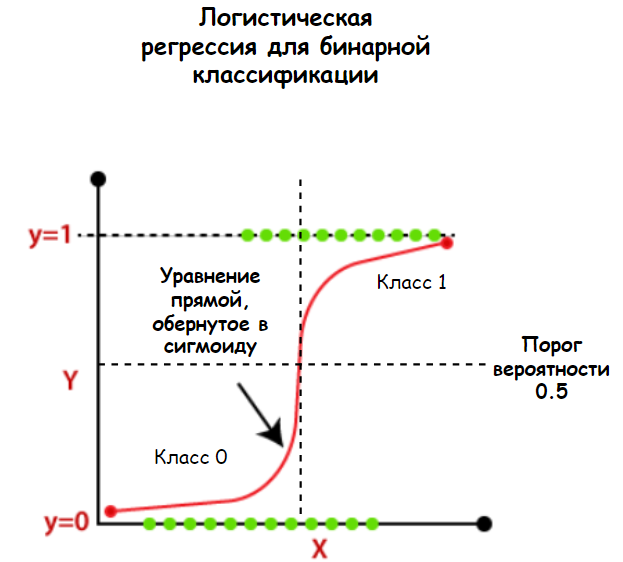

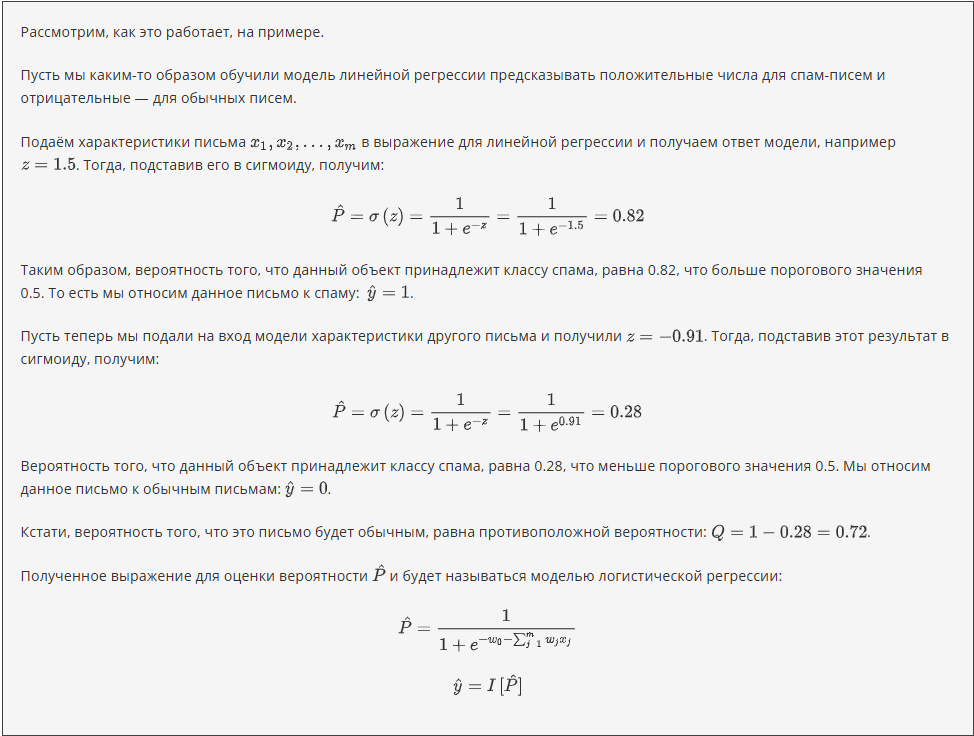

Математически подстановка в уравнение плоскости точки, которая не принадлежит ей (находится ниже или выше), означает вычисление расстояния от этой точки до плоскости.
* Если точка находится ниже плоскости, расстояние будет отрицательным ($z<0$).
* Если точка находится выше плоскости, расстояние будет положительным ($z>0$).
* Если точка находится на самой плоскости, $z=0$.

Мы знаем, что подстановка отрицательных чисел в сигмоиду приведёт к вероятности $\hat{P}<0.5$, а постановка положительных — к вероятности $\hat{P}>0.5$. 

>Таким образом, ключевым моментом в предсказании логистической регрессии является расстояние от точки до разделяющей плоскости в пространстве факторов. Это расстояние в литературе часто называется **отступом (margin)**. 

>Чем больше расстояние от точки, находящейся выше разделяющей плоскости, до самой плоскости, тем больше оценка вероятности принадлежности к классу 1.

Можно построить тепловую карту, которая показывает, чему равны вероятности в каждой точке пространства:

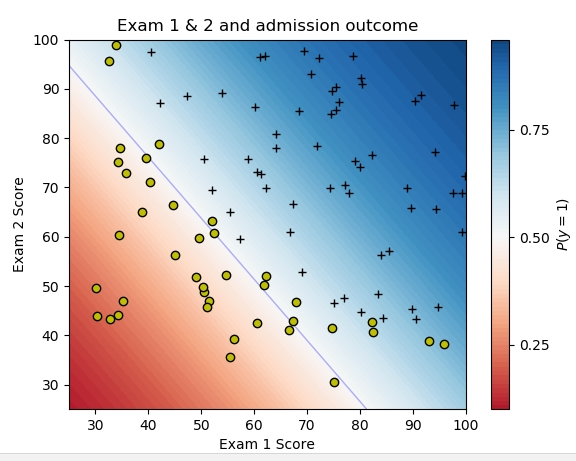

Для случая зависимости целевого признака y от трёх факторов $x_1,x_2,x_3$,  и , например от баллов за два экзамена и рейтинга университета, из которого выпустился абитуриент, выражение для z будет иметь вид:
$$z=w_0+w_1x_1+w_2x_2+w_3x_3$$
Уравнение задаёт плоскость в четырёхмерном пространстве. Но если вспомнить, что y — категориальный признак и классы можно обозначить цветом, то получится перейти в трёхмерное пространство. Разделяющая плоскость будет выглядеть следующим образом:

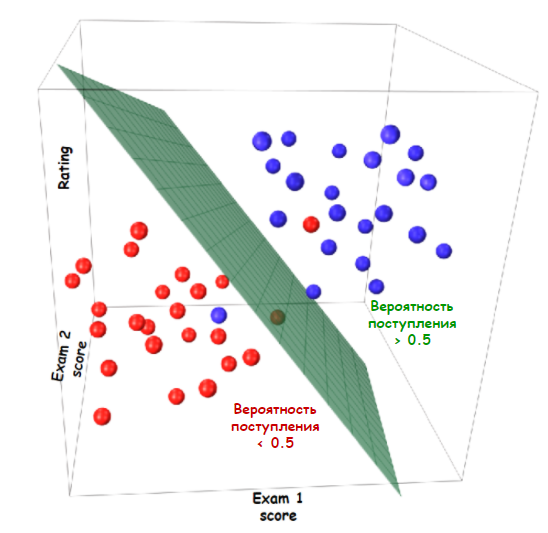

В общем случае, когда у нас есть зависимость от m факторов, линейное выражение, находящееся под сигмоидой, будет обозначать **разделяющую гиперплоскость**.

---

# <center> ПОИСК ПАРАМЕТРОВ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ

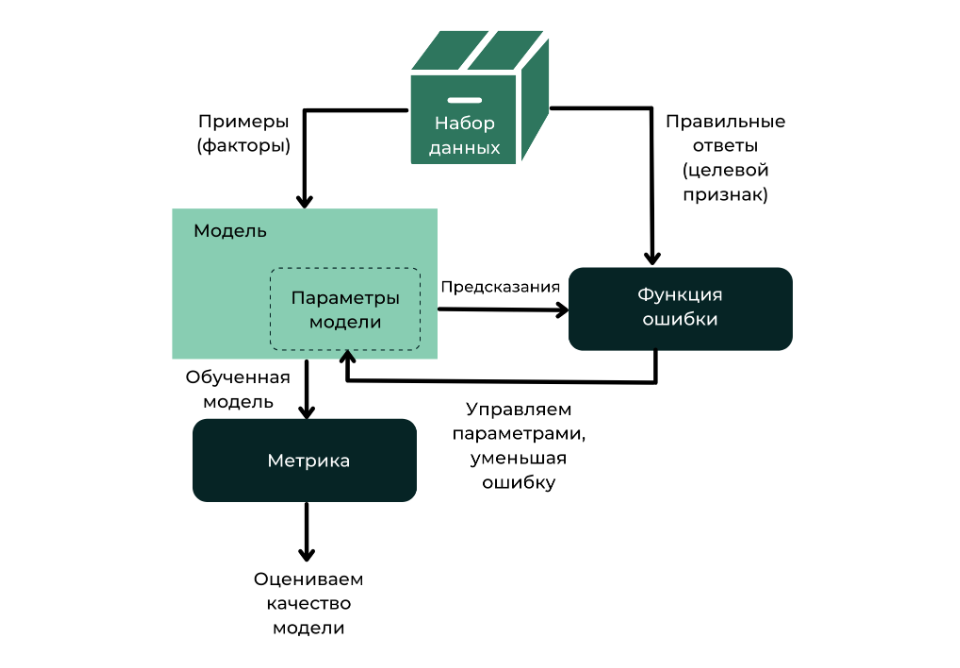

### **Метод максимального правдоподобия (Maximum Likelihood Estimation — MLE)**

>**Правдоподобие** — это оценка того, насколько вероятно получить истинное значение целевой переменной y при данных x и параметрах w. 

**Цель метода** — найти такие параметры $w=(w_0,w_1, \dots, w_m)$, в которых наблюдается максимум функции правдоподобия. Подробнее о выводе формулы вы можете прочитать [здесь](https://habr.com/ru/articles/485872/).

$$likelihood=\sum_{i}^{n}(y_i log(\hat{P_i})+(1-y_i) log(1-\hat{P_i})) \to max_w$$

Давайте разберёмся, что есть что и как работает эта функция.
* n — количество наблюдений.
* $y_i$ — это истинный класс (1 или 0) для i-ого объекта из набора данных.
* $\hat{P_i}$ — предсказанная с помощью логистической регрессии вероятность принадлежности к классу 1 для i-ого объекта из набора данных.
* $z_i$ — результат подстановки i-ого объекта из набора данных в уравнение разделяющей плоскости $z_i=\bar{w \cdot \bar{x}}$.
* log — логарифм (обычно используется натуральный логарифм по основанию e - ln).

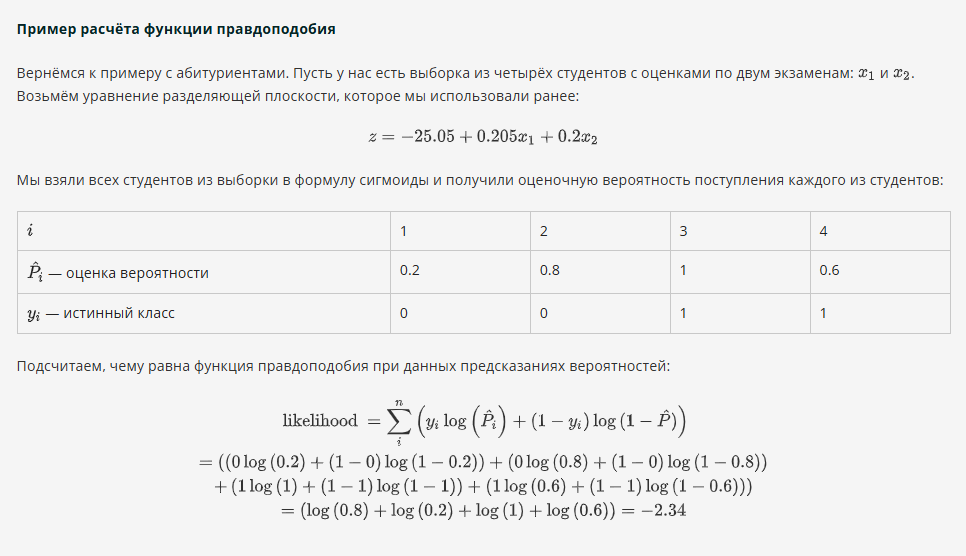

Цель — найти такие параметры, при которых наблюдается максимум этой функции.

Теперь пора снова применить магию математики, чтобы привести задачу к привычному нам формату минимизации эмпирического риска. По правилам оптимизации, если поставить перед функцией минус, то задача оптимизации меняется на противоположную: был поиск максимума — станет поиском минимума.

Таким образом мы получим функцию потерь $L(w)$, которая носит название **«функция логистических потерь»**, или **logloss**. Также часто можно встретить название **кросс-энтропия**, или **cross-entropy loss**:

$$L(w)=logloss= - \sum_{i}^{n}(y_i log(\hat{P_i})+(1-y_i) log(1-\hat{P_i})) \to min_w$$
$$\hat{P_i} = \frac{1}{1+e^{-w_0-\sum_{j=1} ^{m} w_jx_j}}$$

Вот эту функцию мы и будем минимизировать в рамках поиска параметров логистической регрессии. Мы должны найти такие параметры разделяющей плоскости  w, при которых наблюдается минимум logloss.

>К сожалению, для такой функции потерь аналитическое решение оптимизационной задачи найти не получится: при расчётах получается, что его попросту не существует.

Но мы помним, что, помимо аналитических решений, есть и численные.

Например, для поиска параметров можно использовать знакомый нам градиентный спуск. Вспомним, как выглядит итерационная формула данного метода:
$$w^{(k+1)}=w^{(k)} - \eta \bigtriangledown L(w^{(k)})$$

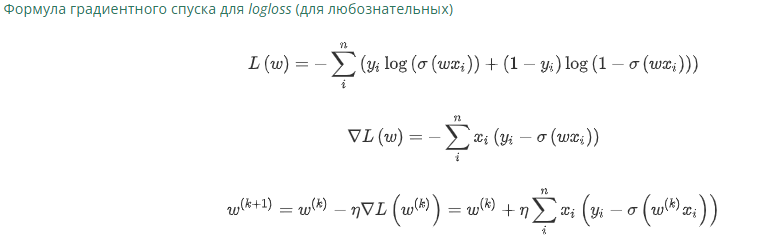

>Мы уже знаем, что для того, чтобы повысить шанс пройти мимо локальных минимумов функции потерь, используется не сам градиентный спуск, а его модификации: например, можно использовать уже знакомый нам стохастический градиентный спуск (SGD).

Во избежание переобучения модели в функцию потерь логистической регрессии традиционно добавляется **регуляризация**. В реализации логистической регрессии в sklearn она немного отличается от той, что мы видели ранее для линейной регрессии.

При L1-регуляризации мы добавляем в функцию потерь $L(w)$ штраф из суммы модулей параметров, а саму функцию logloss умножаем на коэффициент C:
$$L(w)= C \cdot logloss + \sum_{j=1} ^{m} |w_j| \to min_w$$
А при L2-регуляризации — штраф из суммы квадратов параметров:
$$L(w) = C \cdot logloss + \sum_{j=1} ^{m} (w_j)^2 \to min_w $$


Значение коэффициента  C — коэффициент, обратный коэффициенту регуляризации. Чем больше C, тем меньше «сила» регуляризации.

---

# <center> **ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ В SKLEARN**

In [1]:
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации


import warnings # для игнорирования предупреждений
#Игнорируем предупреждения
warnings.filterwarnings('ignore')


# Устанавливаем стиль визуализаций в matplotlib
%matplotlib inline
plt.style.use('seaborn-v0_8')

In [2]:
diabetes_data = pd.read_csv('data_ml3/diabetes_cleaned.csv')
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,98.0,58.0,33.0,34.0,0.430,43,0
1,2,112.0,75.0,32.0,35.7,0.148,21,0
2,2,108.0,64.0,29.0,30.8,0.158,21,0
3,8,107.0,80.0,29.0,24.6,0.856,34,0
4,7,136.0,90.0,29.0,29.9,0.210,50,0


Напомним, какие признаки у нас есть:
* Pregnancies — количество беременностей;
* Glucose — концентрация глюкозы в плазме через два часа при пероральном тесте на толерантность к глюкозе;
* BloodPressure — диастолическое артериальное давление (мм рт. ст.);
* SkinThickness — толщина кожной складки трицепса (мм);
* BMI — индекс массы тела (вес в кг/рост в м)^2;
* DiabetesPedigreeFunction — функция родословной диабета (чем она выше, тем выше шанс наследственной заболеваемости);
* Age — возраст;
* Outcome — наличие диабета (0 — нет, 1 — да), **целевой признак**.

Размер таблицы:

In [3]:
print(diabetes_data.shape)

(757, 8)


Давайте посмотрим на матрицу корреляций и выберем наиболее коррелированные с целевым признаком факторы:

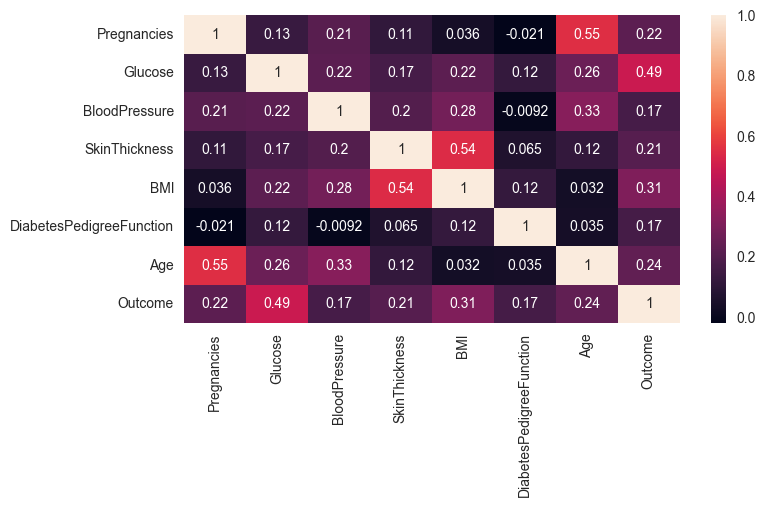

In [4]:
fig, ax = plt.subplots(figsize = (8, 4))
sns.heatmap(diabetes_data.corr(), annot=True);

Из строки Outcome видно, что наибольшей корреляцией с целевым признаком обладают факторы Glucose (уровень глюкозы) и BMI (индекс массы тела).

Построим диаграмму рассеяния, по оси абсцисс отложим фактор Glucose, а по оси ординат — BMI. Сделаем цветовую группировку по признаку наличия диабета:

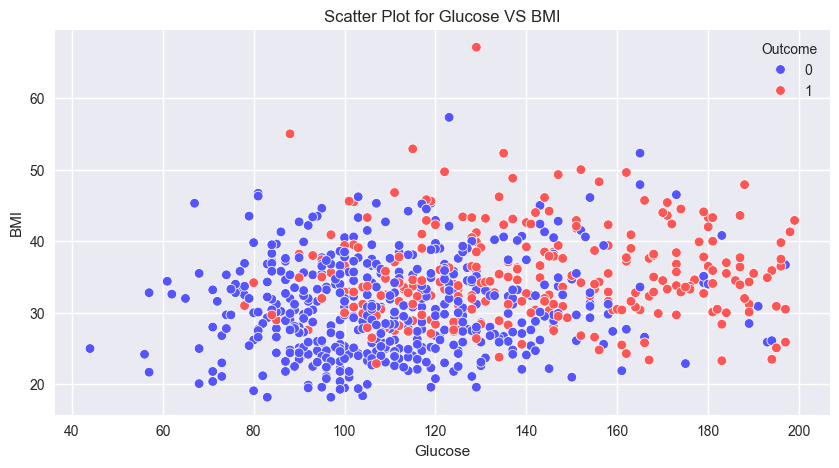

In [5]:
fig, ax = plt.subplots(figsize = (10, 5)) #фигура + координатная плоскость
#Строим диаграмму рассеяния
sns.scatterplot(
    data=diabetes_data, #датасет
    x='Glucose', #ось абсцисс
    y='BMI', #ось ординат
    hue='Outcome', #группировка
    palette='seismic', #палитра
    ax=ax, #координатная плоскость
);

#Задаём название графику
ax.set_title('Scatter Plot for Glucose VS BMI');

Видно, что классы довольно сильно перемешаны, но красные точки, соответствующие пациентам с диабетом, преимущественно сгруппированы в правой части системы координат.

Давайте попробуем построить разделяющую плоскость с помощью логистической регрессии.

Для начала разделим выборку на матрицу наблюдений X, состоящую из двух признаков, и столбец с правильным ответами y:

In [6]:
#Создаём матрицу наблюдений X и столбец с ответами y
X = diabetes_data[['Glucose', 'BMI']]
y = diabetes_data['Outcome']

Логистическая регрессия — линейная модель, поэтому она находится в уже знакомом нам модуле linear_model из библиотеки sklearn.

In [7]:
from sklearn import linear_model #линейные модели

В модуле находится класс ```LogisticRegression```, который реализует поиск коэффициентов разделяющей плоскости путём минимизации функции потерь ```logloss``` различными численными методами.

**Основные параметры LogisticRegression**:
* ```random_state``` — число, на основе которого происходит генерация случайных чисел.
* ```penalty``` — метод регуляризации. Возможные значения:
    * ```'l1'``` — L1-регуляризация;
    * ```'l2'``` — L2-регуляризация (используется по умолчанию);
    * ```'elasticnet'``` — эластичная сетка (L1+L2);
    * ```'None'``` — отсутствие регуляризации.
* ```C``` — коэффициент обратный коэффициенту регуляризации, то есть равен $\frac{1}{\alpha}$. Чем больше C, тем меньше регуляризация. По умолчанию C=1, тогда α=1.
* ```solver``` — численный метод оптимизации функции потерь logloss, может быть:
    * ```'sag'``` — стохастический градиентный спуск (нужна стандартизация/нормализация);
    * ```'saga'``` — модификация предыдущего, которая поддерживает работу с негладкими функциями (нужна стандартизация/нормализация);
    * ```'newton-cg'``` — [метод Ньютона с модификацией сопряжённых градиентов](https://docs.scipy.org/doc/scipy/tutorial/optimize.html#newton-conjugate-gradient-algorithm-method-newton-cg) (не нужна стандартизация/нормализация);
    * ```'lbfgs'``` — [метод Бройдена — Флетчера — Гольдфарба — Шанно](https://ru.wikipedia.org/wiki/Алгоритм_Бройдена_—_Флетчера_—_Гольдфарба_—_Шанно) (не нужна стандартизация/нормализация; используется по умолчанию, так как из всех методов теоретически обеспечивает наилучшую сходимость);
    * ```'liblinear'``` — [метод покоординатного спуска](http://www.machinelearning.ru/wiki/index.php?title=Метод_покоординатного_спуска) (не нужна стандартизация/нормализация).
* ```max_iter``` — максимальное количество итераций, выделенных на сходимость.

Обучим логистическую регрессию, сделав значением параметра ```random_state```, например, число 42 (традиционное число, которое означает ответ на вопрос о смысле жизни), чтобы гарантировано получить одинаковые результаты. Остальные параметры оставим по умолчанию.

Для обучения модели необходимо просто вызвать метод ```fit()```, передав в него матрицу наблюдений ```X``` и вектор правильных ответов ```y```.

Чтобы получить параметр $w_0$, нужно обратиться к атрибуту ```intercept_```, а вектор параметров  $w_1$, $w_2$, ..., $w_m$ будет храниться в атрибуте ```coef_ ```(так как в матрице X два фактора, то и коэффициента будет два):

In [8]:
#Создаём объект класса LogisticRegression
log_reg_2d = linear_model.LogisticRegression(random_state=42)
#Обучаем модель, минимизируя logloss
log_reg_2d.fit(X, y)
#Выводим результирующие коэффициенты
print('w0: {}'.format(log_reg_2d.intercept_)) #свободный член w0
print('w1, w2: {}'.format(log_reg_2d.coef_)) #остальные параметры модели w1, w2, ..., wm

w0: [-8.24901758]
w1, w2: [[0.03779291 0.08757414]]


Мы должны подставить значения факторов в уравнение разделяющей плоскости, а затем результат подставить в функцию сигмоиды. Как хорошо, что для этого есть метод ```predict_proba()```.

Например, появился новый пациент с концентрацией глюкозы 180 мг/100мл и индексом массы тела в 51 $кг/м^2$. Мы хотим вычислить вероятность наличия/отсутствия диабета у данного пациента:

In [9]:
#Значения концентрации глюкозы и индекса массы тела для пациента
x_new = pd.DataFrame({'Glucose': [180], 'BMI': [51]})
#Делаем предсказание вероятностей:
y_new_proba_predict = log_reg_2d.predict_proba(x_new)
print('Predicted probabilities: {}'.format(np.round(y_new_proba_predict, 2)))

Predicted probabilities: [[0.05 0.95]]


Метод predict_proba() возвращает сразу две вероятности: первая соответствует вероятности принадлежности к классу 0 (диабета нет), а вторая — вероятности принадлежности к классу 1 (диабет есть). Заметьте, что в сумме две вероятности дают 1, что вполне логично, так как события взаимоисключающие.

Если мы хотим предсказать не вероятности, а сам класс (1 или 0), нам пригодится метод ```predict()```. По умолчанию метод predict() относит объект к классу 1, если вероятность принадлежности к классу 1 > 0.5, и к классу 0, если эта вероятность < 0.5.

In [10]:
#Значения концентрации глюкозы и индекса массы тела для пациента
x_new = pd.DataFrame({'Glucose': [180], 'BMI': [51]})
#Делаем предсказание класса:
y_new_predict = log_reg_2d.predict(x_new)
print('Predicted class: {}'.format(y_new_predict))

Predicted class: [1]


Предсказанный класс равен 1: значит, модель считает, что данный пациент болеет диабетом.

Теперь построим визуализацию нашей модели.

Чтобы красиво визуализировать вероятности в виде тепловой карты, мы подготовили для вас специальную функцию — ```plot_probabilities_2d()```.

Данная функция принимает три аргумента:
* X — матрица с наблюдениями,
* y — столбец с правильными ответами,
* model — модель, с помощью которой делается предсказание вероятностей.

In [11]:
#Функция для визуализации модели
def plot_probabilities_2d(X, y, model):
    #Генерируем координатную сетку из всех возможных значений для признаков
    #Glucose изменяется от x1_min = 44 до x2_max = 199, 
    #BMI — от x2_min = 18.2 до x2_max = 67.1
    #Результат работы функции — два массива xx1 и xx2, которые образуют координатную сетку
    xx1, xx2 = np.meshgrid(
        np.arange(X.iloc[:, 0].min()-1, X.iloc[:, 0].max()+1, 0.1),
        np.arange(X.iloc[:, 1].min()-1, X.iloc[:, 1].max()+1, 0.1)
    )
    #Вытягиваем каждый из массивов в вектор-столбец — reshape(-1, 1)
    #Объединяем два столбца в таблицу с помощью hstack
    X_net = np.hstack([xx1.reshape(-1, 1), xx2.reshape(-1, 1)])
    #Предсказываем вероятность для всех точек на координатной сетке
    #Нам нужна только вероятность класса 1
    probs = model.predict_proba(X_net)[:, 1]
    #Переводим столбец из вероятностей в размер координатной сетки
    probs = probs.reshape(xx1.shape)
    #Создаём фигуру и координатную плоскость
    fig, ax = plt.subplots(figsize = (10, 5))
    #Рисуем тепловую карту вероятностей
    contour = ax.contourf(xx1, xx2, probs, 100, cmap='bwr')
    #Рисуем разделяющую плоскость — линию, где вероятность равна 0.5
    bound = ax.contour(xx1, xx2, probs, [0.5], linewidths=2, colors='black');
    #Добавляем цветовую панель 
    colorbar = fig.colorbar(contour)
    #Накладываем поверх тепловой карты диаграмму рассеяния
    sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=y, palette='seismic', ax=ax)
    #Даём графику название
    ax.set_title('Scatter Plot with Decision Boundary');
    #Смещаем легенду в верхний левый угол вне графика
    ax.legend(bbox_to_anchor=(-0.05, 1))

Теперь вызовем нашу функцию и посмотрим, как логистическая вероятность делит пространство на две части.

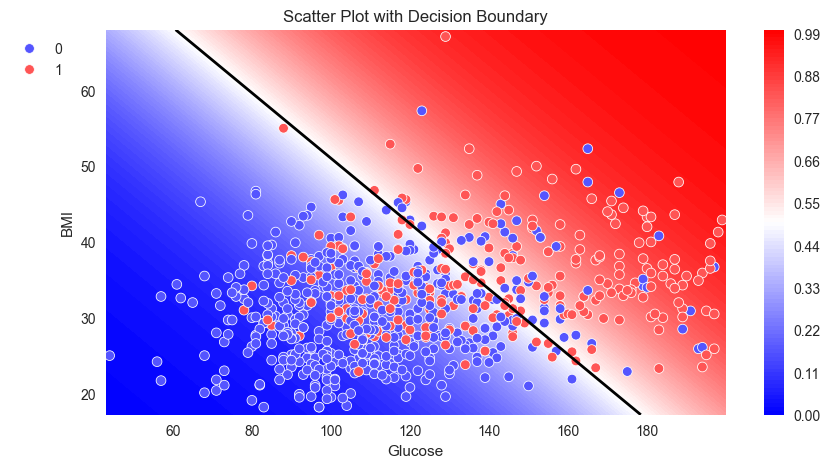

In [12]:
plot_probabilities_2d(X, y, log_reg_2d)

Мы видим разделяющую поверхность (обозначена чёрной линией). Она делит пространство на две части: красное соответствует точкам, которые будут отнесены моделью к классу 1, а синее соответствует точкам, которые будут отнесены моделью к классу 0.

Справа от графика есть цветовая панель, которая показывает значение вероятности того, что пациент болен диабетом (по мнению модели).

>Обратите внимание, что чем более точка удалена от разделяющей плоскости, тем с большей вероятностью модель относит её к тому или иному классу. На тепловой карте это прослеживается в интенсивности синего и красного цвета.

Из графика видно, что довольно много синих точек попали в красную зону и наоборот. Видимо, информации о двух факторах всё же маловато для того, чтобы хорошо провести классификацию.

Давайте будем использовать для построения модели всю предоставленную нам информацию — все факторы из набора данных. Для этого заново создадим матрицу наблюдений X и вектор ответов y:

---

In [13]:
#Создаём матрицу признаков X и столбец с ответами y
X = diabetes_data.drop('Outcome', axis=1)
y = diabetes_data['Outcome']

Затем обучим модель логистической регрессии с помощью метода ```fit()```.

Сделаем предсказание вероятности заболевания диабетом для каждого пациента и самих классов с помощью методов ```predict_proba()``` и ```predict()```.

In [14]:
#Создаём объект класса LogisticRegression
log_reg_full = linear_model.LogisticRegression(random_state=42, max_iter=1000)
#Обучаем модель, минимизируя logloss
log_reg_full.fit(X, y)
#Делаем предсказание класса
y_pred = log_reg_full.predict(X)

Затем добавим предсказание в таблицу X для наглядности:

In [15]:
#Создадим временную таблицу X
X_temp = X.copy()
#Добавим в эту таблицу результат предсказания
X_temp['Prediction'] = y_pred
X_temp.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Prediction
752,5,139.0,64.0,35.0,28.6,0.411,26,0
753,1,96.0,122.0,29.0,22.4,0.207,27,0
754,10,101.0,86.0,37.0,45.6,1.136,38,1
755,0,141.0,72.0,29.0,42.4,0.205,29,1
756,0,125.0,96.0,29.0,22.5,0.262,21,0


Итак, мы сделали предсказание для каждого наблюдения (пациента) из таблицы X.

К сожалению, теперь, когда признаков больше двух, построить красивую визуализацию разделяющей плоскости не получится.

→ Но как же тогда узнать, насколько хорошо модель определяет наличие диабета у пациента? Для этого используются метрики классификации

---

In [16]:
data = pd.read_csv('data_ml3/task_data.csv')
data.head()

,SNo,X_1,X_2,y
0,0,-0.869144,0.389310,0.0
1,1,-0.993467,-0.610591,0.0
2,2,-0.834064,0.239236,0.0
3,3,-0.136471,0.632003,1.0
4,4,0.403887,0.310784,1.0


In [17]:
data.shape

(100, 4)

Таблица состоит из четырёх столбцов:
* SNo — номер строки (данный столбец вам не понадобится, вы можете сразу его удалить);
* X_1 и X_2 — факторы;
* y — целевой признак.

In [18]:
X = data[['X_1', 'X_2']]
y = data['y']

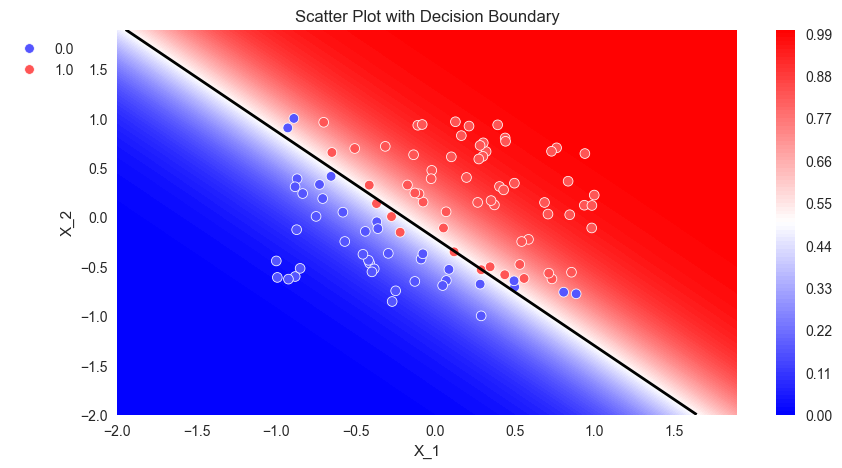

In [19]:
#Создаём объект класса LogisticRegression
log_reg = linear_model.LogisticRegression(random_state=42, solver = 'sag')
#Обучаем модель, минимизируя logloss
log_reg.fit(X, y)
plot_probabilities_2d(X, y, log_reg)

---

# <center> **Метрики классификации**

Мы случайным образом выбрали десять пациентов из нашей таблицы и моделью log_reg_full предсказали для них ответы:
$$y=(1,0,1,1,0,1,1,0,1,1)$$
$$\hat{y}=(1,1,0,1,0,0,1,1,0,1)$$

Все метрики, которые мы рассмотрим, основаны на матрице ошибок. С неё мы и начнём наш разбор.

---

>**1**

>**Матрица ошибок (confusion matrix)** показывает все возможные исходы совпадения и несовпадения предсказания модели с действительностью. Используется для расчёта других метрик.

Допустим, что у нас есть два класса и алгоритм, предсказывающий принадлежность каждого объекта к одному из классов. Тогда каждая ячейка матрицы ошибок соответствует количеству объектов, попавших в одну из следующих четырёх категорий:
* **Истинно положительные (True Positive, TP)** — это объекты, обозначенные моделью как класс 1 ($\hat{y}=1$) и действительно принадлежащие к классу 1 (y=1).
* **Ложноположительные (False Positive, FP)** — это объекты, обозначенные моделью как класс 1 ($\hat{y}=1$), но в действительности принадлежащие к классу 0 (y=0). То есть это объекты, для которых модель совершила ошибку I рода.
* **Истинно отрицательные (True Negative, TN)** — это объекты, обозначенные моделью как класс 0 ($\hat{y}=0$) и действительно принадлежащие к классу 0 (y=0).
* **Ложноотрицательные (False Negative, FN)** — это объекты, обозначенные моделью как класс 0 ($\hat{y}=0$), но в действительности принадлежащие к классу 1 (y=1). То есть это объекты, для которых модель совершила ошибку II рода.

Общий вид матрицы ошибок будет следующим:

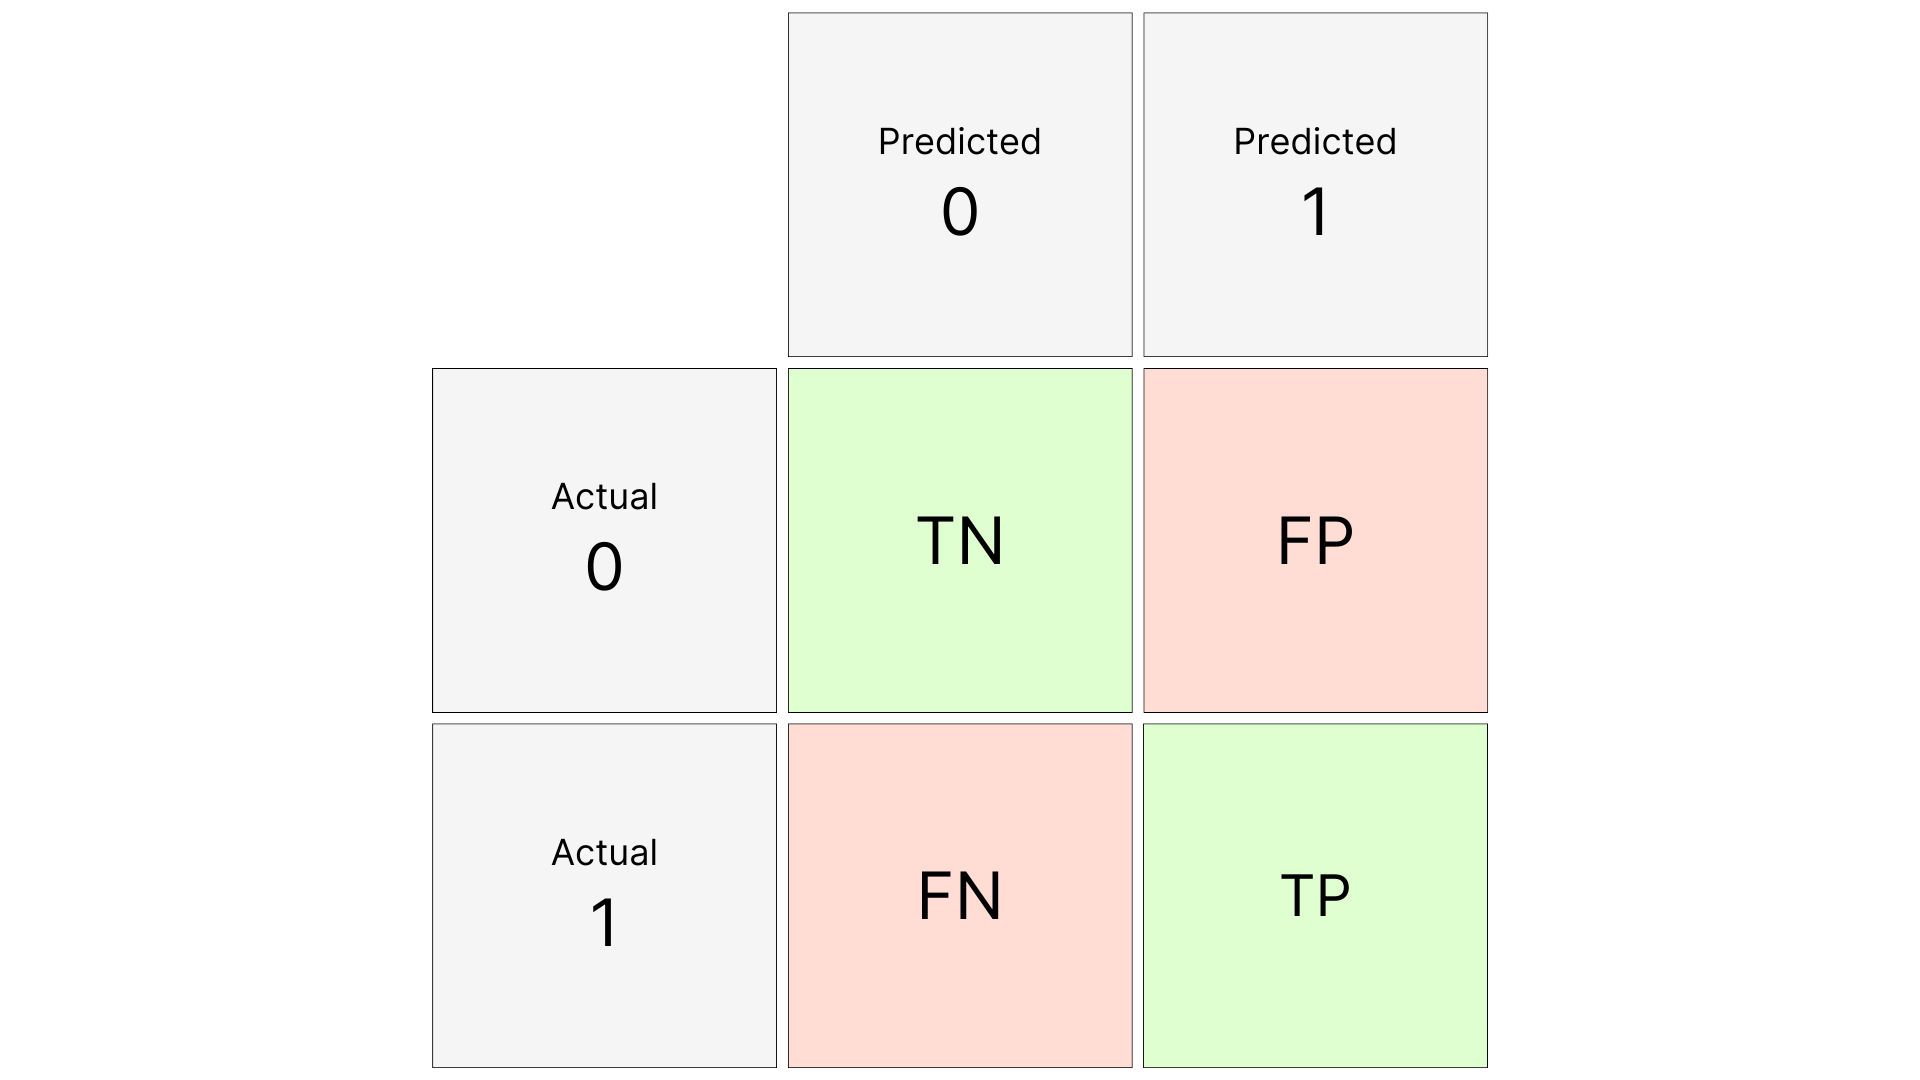

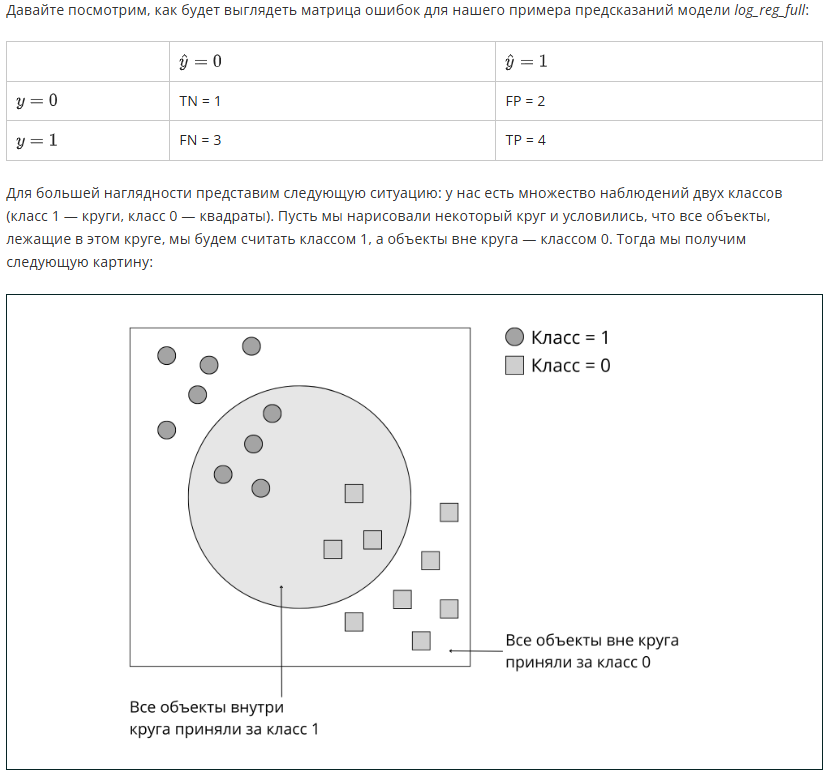

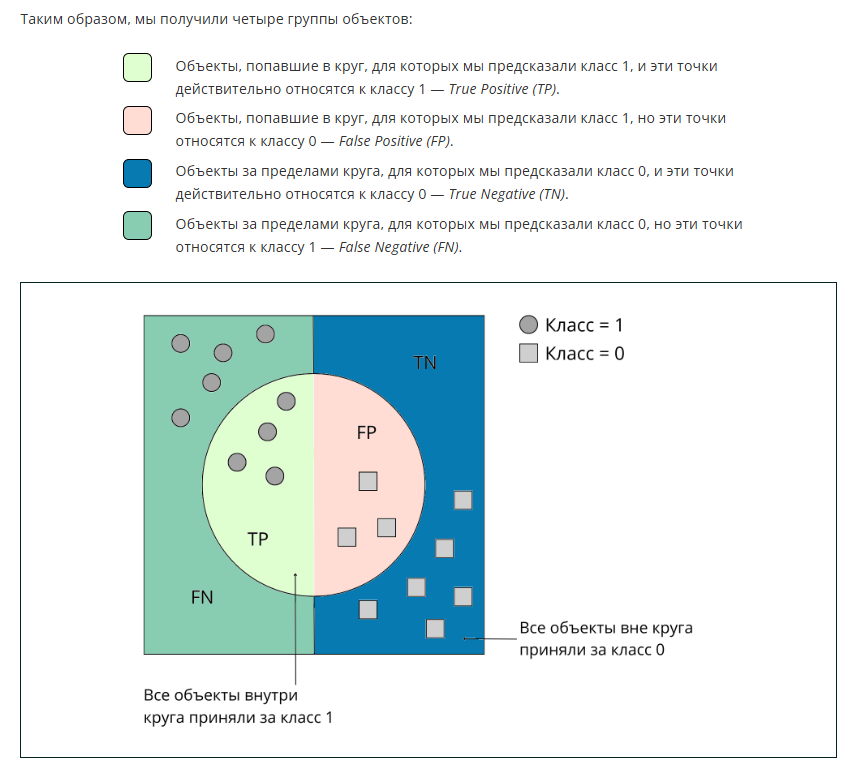

Формально матрица ошибок не является метрикой, но на её основе составляются сами метрики классификации.

---

> **2**

>**Accuracy (достоверность/аккуратность)** — доля правильных ответов модели среди всех ответов. Правильные ответы — это истинно положительные (True Positive) и истинно отрицательные ответы (True Negative):

> $$accuracy=\frac{TP+TN}{TP+TN+FN+FP}$$

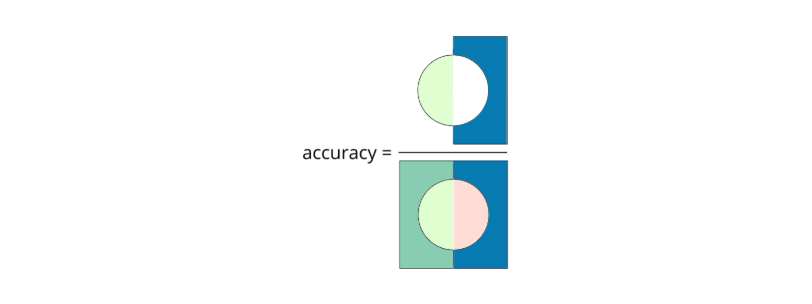

>**Интерпретация**: как много (в долях) модель угадала ответов.

Метрика изменяется в диапазоне от 0 до 1. Чем ближе значение к 1, тем больше ответов модель «угадала». 

Рассчитаем accuracy для нашего примера:
$$accuracy=\frac{4+1}{4+2+3+1}=0.5$$

Итак, наша accuracy равна 0.5, то есть модель сделала верное предсказание для 50 % пациентов из выборки.

>Accuracy — самая простая и самая понятная метрика классификации, но у неё есть один существенный недостаток. Она бесполезна, если классы сильно несбалансированы, то есть в каждом из классов сильно отличается количество примеров..

 Преодолеть это нам поможет переход с общей для всех классов метрики к отдельным показателям качества классов, а именно к метрикам precision, recall и F-мера.

---

> **3**

>**Precision (точность)**, или **PPV (Positive Predictive Value)** — это доля объектов, названных классификатором положительными и при этом действительно являющихся таковыми, по отношению ко всем названным положительными объектам.

> $$precision=\frac{TP}{TP+FP}$$

В виде диаграммы соотношение количества объектов класса 1, которые мы угадали и количества объектов, которые мы приняли за класс 1, записывается следующим образом:

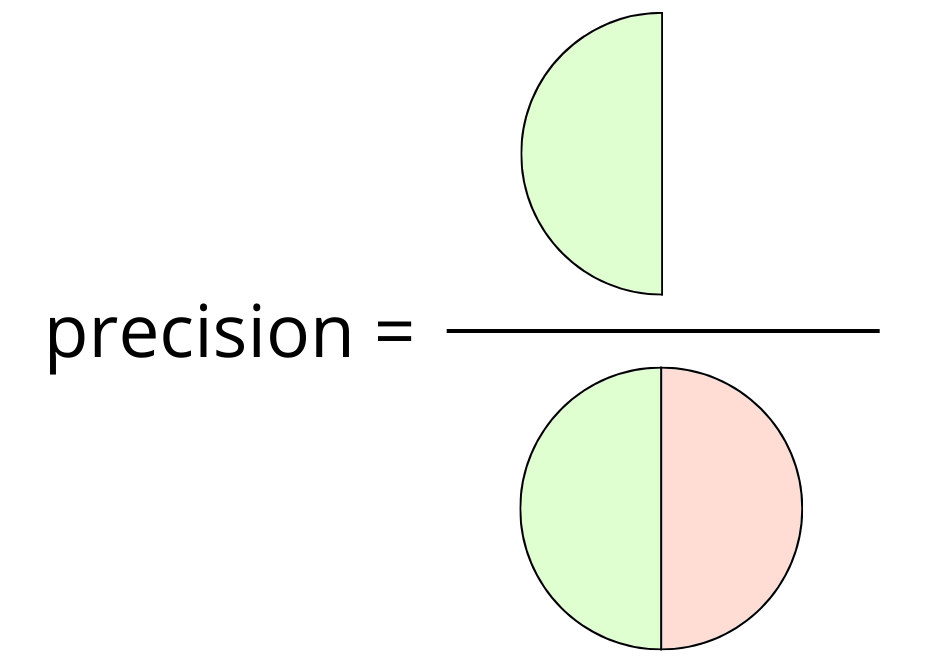

Метрика также изменяется от 0 до 1. 

>**Интерпретация**: способность отделить класс 1 от класса 0. Чем больше precision, тем меньше ложных попаданий. **То есть чем ближе precision к 1, тем меньше вероятность модели допустить ошибку I рода.**

Именно precision не позволяет записать все ответы в один класс, так как в таком случае резко возрастает значение False Positive и метрика снижается.

Рассчитаем precision для нашего примера:
$$precision=\frac{4}{4+2}=0.67$$

Таким образом, количество названных моделью больных диабетом и при этом действительно являющихся больными составляет 67 % от всех пациентов.

Precision нужен в задачах, где от нас требуется минимум ложных срабатываний. Чем выше «цена» ложноположительного результата, тем выше должен быть precision.

В предельном случае (когда precision равен 1) у модели отсутствуют ложноположительные срабатывания.

>**Примечание**. Важно понимать, что данный вывод справедлив только для выборки, на которой мы оцениваем метрику, то есть это не означает, что модель вовсе не может допустить ложноположительных результатов. Однако чем больше выборка, на которой мы тестируем алгоритм, тем ближе к истине будет данный вывод.

---

> **4**

>**Recall (полнота)**, или **TPR (True Positive Rate)** — это доля объектов, названных классификатором положительными и при этом действительно являющихся таковыми, по отношению ко всем объектам положительного класса.

> $$recall=\frac{TP}{TP+FN}$$

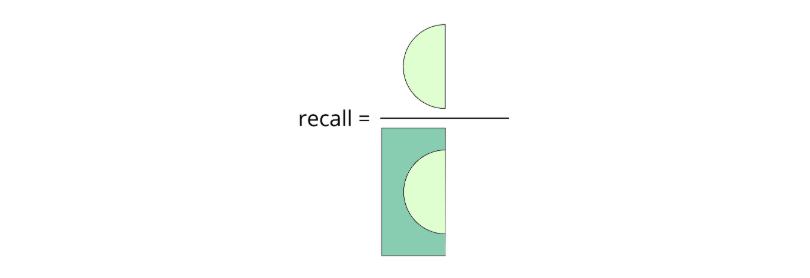

Метрика изменяется от 0 до 1.

>**Интерпретация**: способность модели обнаруживать класс 1 вообще, то есть охват класса 1. Заметьте, что метрика зависит от количества ложноотрицательных срабатываний. **То есть чем ближе recall к 1, тем меньше вероятность модели допустить ошибку II рода**.

Рассчитаем recall для нашего примера:
$$recall=\frac{4}{4+3}=0.57$$
Итак, процент пациентов, которых модель определила к классу больных диабетом, среди всех действительно больных диабетом составляет 57 %.

>Recall очень хорошо себя показывает в задачах, где важно найти как можно больше объектов, принадлежащих к классу 1.

Например, это различные задачи, в которых мы пытаемся определить наличие эффекта, который может привести к серьёзным последствиям. Это могут быть те же диагностические задачи или задачи, в которых мы прогнозируем вероятность отказа устройства, от работы которого зависят человеческие жизни.

Предельный случай (когда recall равен 1) означает, что модель нашла все объекты класса 1, например всех действительно больных пациентов. Однако метрика ничего не скажет о том, с какой точностью мы это сделали.

>Примечание. Важно понимать, что данный вывод справедлив только для выборки, на которой мы оцениваем метрику, то есть это не означает, что модель вовсе не может допустить ложноотрицательных исходов. Однако чем больше выборка, на которой мы тестируем алгоритм, тем данный вывод будет ближе к истине.

Метрики precision и recall не зависят от сбалансированности классов и в совокупности дают довольно исчерпывающее представление о классификаторе. Однако на практике часто бывает так, что **увеличение одной из метрик может привести к уменьшению другой**.

---

>**5**

> $F_{\beta}$(**F-мера**) — это взвешенное среднее гармоническое между precision и recall:
$$F_{\beta}=(1+ \beta^2) \frac{precision \cdot recall}{(\beta^2 precision) + recall}$$

> где $\beta$ — это вес precision в метрике: чем больше $\beta$, тем больше вклад.

В частном случае, когда $\beta=1$, мы получаем равный вклад для precision и recall, а формула будет выражать простое среднее гармоническое, или метрику  $F_1$($F_1$-мера):

$$F_1=2\frac{precision \cdot recall}{precision + recall}$$

Рассчитаем метрику $F_1$ для нашего примера:
$$F_1=2\frac{0.67 \cdot 0.57}{0.67+0.57}=0.62$$

В чём преимущество $F_1$-меры?

Метрика равна своему максимуму (1), если и precision, и recall равны 1 (то есть когда отсутствуют как ложноположительные, так и ложноотрицательные срабатывания). Но если хотя бы одна из метрик будет близка к 0, то и $F_1$ будет близка к 0. 

Несмотря на отсутствие бизнес-интерпретации, метрика $F_1$ является довольно распространённой и используется в задачах, где необходимо выбрать модель, которая балансирует между precision и recall.

Например, если цена дополнительной диагностики заболевания очень высока, то есть ложных срабатываний должно быть минимум, но при этом нам важно охватить как можно больше больных пациентов. 

>Примечание. Ещё одно небольшое, но очень важное замечание: все суждения, которые мы привели по отношению к precision, recall и F-мере, относятся только к классу 1, так как эти метрики по умолчанию считаются для класса 1. Для решения большинства задач знания о значении этих метрик для класса 1 более чем достаточно, так как обычно нас интересует именно наличие некоторого эффекта.

>Однако если вам по каким-то причинам необходимо рассчитать precision, recall и F-меру для класса 0, для этого достаточно сделать перекодировку классов — поменять их обозначения местами или (при расчёте метрик с помощью библиотеки sklearn) изменить значение специального параметра ```pos_label``` на 0.

---

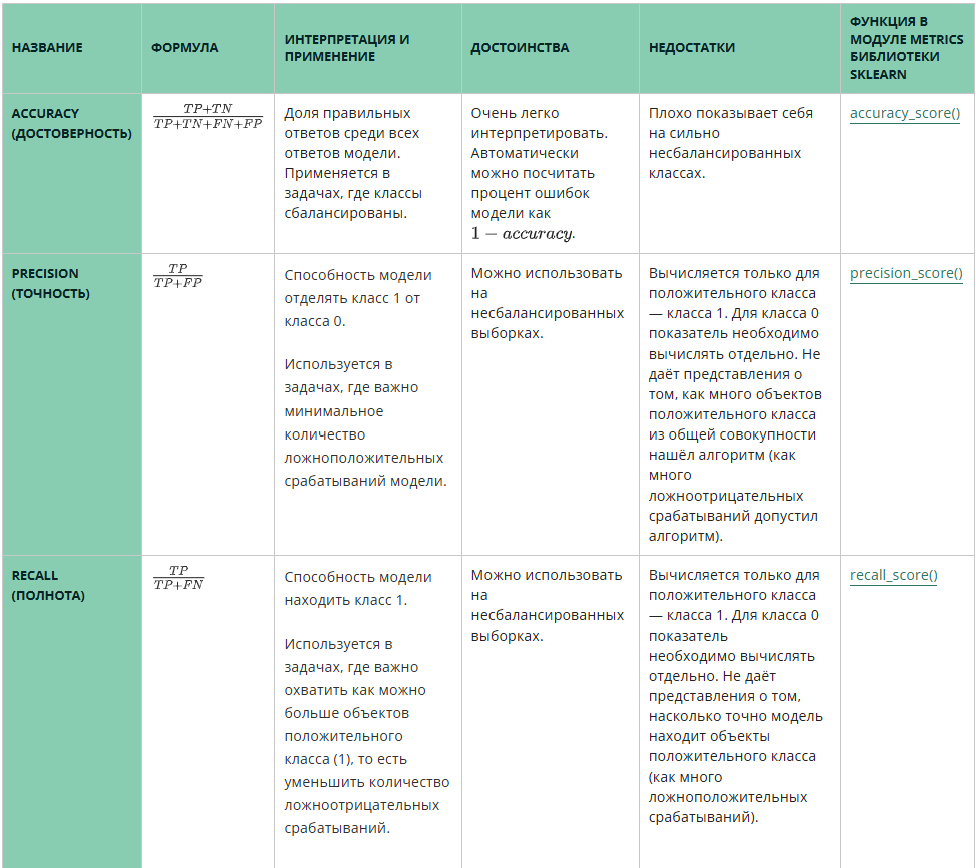
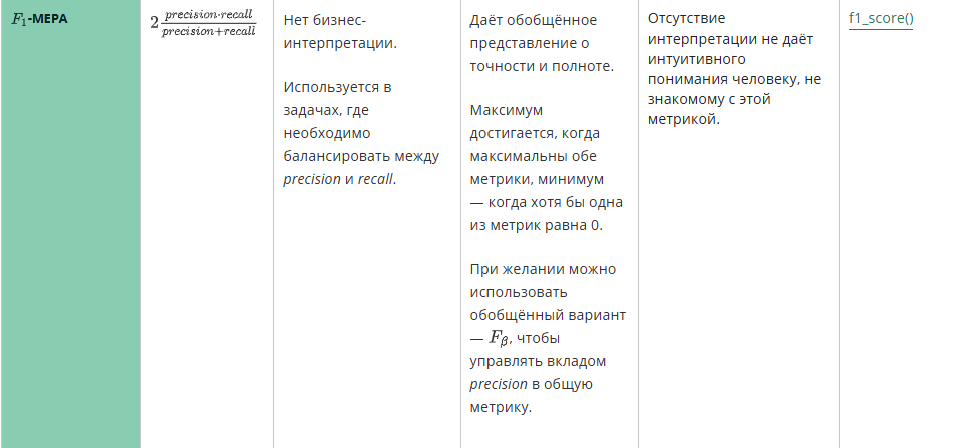

* [accuracy_score()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)
* [precision_score()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html#sklearn.metrics.precision_score)
* [recall_score()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html#sklearn.metrics.recall_score)
* [f1_score()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score)

---

## РАСЧЁТ МЕТРИК НА PYTHON

Весь набор функций для вычисления метрик в sklearn находится в модуле [metrics](https://scikit-learn.org/stable/api/index.html). Давайте его импортируем:

In [20]:
from sklearn import metrics

Функции, которые нам понадобятся:
* ```confusion_matrix()``` — расчёт матрицы ошибок,
* ```accuracy_score()``` — расчёт accuracy,
* ```precision_score()``` — расчёт precision,
* ```recall_score()``` — расчёт recall,
* ```f1_score()``` — расчёт $F_1$-меры.

Каждая из этих функций первым аргументом принимает истинные ответы y, а вторым аргументом — предсказанные значения целевой переменной $\hat{y}$.

Давайте составим матрицы ошибок для моделей log_reg_2d и log_reg_full, которые мы обучили в прошлом юните.

Для этого сделаем предсказание наличия диабета для всех пациентов с помощью каждой из моделей:

In [21]:
#Делаем предсказание моделью, обученной на двух признаках 
y_pred1 = log_reg_2d.predict(diabetes_data[['Glucose', 'BMI']])
#Делаем предсказание моделью, обученной на всех признаках 
y_pred2 = log_reg_full.predict(diabetes_data.drop('Outcome', axis=1))

Построим матрицы ошибок для каждой модели, а затем отобразим их в виде тепловых карт:

In [22]:
#Строим матрицы ошибок для каждой из моделей
confusion_matrix1 = metrics.confusion_matrix(y, y_pred1)
confusion_matrix2 = metrics.confusion_matrix(y, y_pred2)
#Визуализируем матрицы ошибок
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) #фигура + 2 координатные плоскости
#Строим тепловую карту для первой матрицы ошибок
sns.heatmap(confusion_matrix1, annot=True, fmt='', ax=axes[0], cmap='Blues')
#Добавляем название графику и подписи осей абсцисс и ординат
axes[0].set_title('Confusion matrix for log_reg_2d')
axes[0].set_xlabel('y prediction')
axes[0].set_ylabel('y true')
#Строим тепловую карту для второй матрицы ошибок
sns.heatmap(confusion_matrix2, annot=True, fmt='', ax=axes[1], cmap='Blues')
#Добавляем название графику и подписи осей абсцисс и ординат
axes[1].set_title('Confusion matrix for log_reg_full')
axes[1].set_xlabel('y prediction')
axes[1].set_ylabel('y true');

ValueError: Found input variables with inconsistent numbers of samples: [100, 757]

Видно, что матрицы ошибок незначительно отличаются по своим составляющим. На их основе можно вручную вычислить остальные метрики для каждой из моделей, но мы воспользуемся встроенными функциями.

Расчёт метрик для модели log_reg_2d, обученной на двух факторах — Glucose и BMI:

In [ ]:
#Модель log_reg_2d:
#Рассчитываем accuracy
print('Accuracy: {:.2f}'.format(metrics.accuracy_score(y, y_pred1)))
#Рассчитываем precision
print('Precision: {:.2f}'.format(metrics.precision_score(y, y_pred1)))
#Рассчитываем recall
print('Recall: {:.2f}'.format(metrics.recall_score(y, y_pred1)))
#Рассчитываем F1-меру
print('F1 score: {:.2f}'.format(metrics.f1_score(y, y_pred1)))

Accuracy: 0.76
Precision: 0.71
Recall: 0.53
F1 score: 0.61


Расчёт метрик для модели log_reg_full, обученной на всех доступных факторах:

In [ ]:
#Модель log_reg_full:
#Рассчитываем accuracy
print('Accuracy: {:.2f}'.format(metrics.accuracy_score(y, y_pred2)))
#Рассчитываем precision
print('Precision: {:.2f}'.format(metrics.precision_score(y, y_pred2)))
#Рассчитываем recall
print('Recall: {:.2f}'.format(metrics.recall_score(y, y_pred2)))
#Рассчитываем F1-меру
print('F1 score: {:.2f}'.format(metrics.f1_score(y, y_pred2)))

Accuracy: 0.77
Precision: 0.72
Recall: 0.56
F1 score: 0.63


А теперь давайте сравним:
* Accuracy: доля правильных ответов для первой модели составляет 0.76, для второй — 0.77.
* Precision: способность первой модели отделять больных диабетом пациентов от здоровых пациентов составляет 0.71, а второй — 0.72.
* Recall: обобщающая способность находить больных пациентов среди всех пациентов для первой модели — 0.53, а для второй — 0.56.
* $F_1$: среднее гармоническое между precision и recall для первой модели составляет 0.61, а для второй — 0.63.

Видно, что хоть и с небольшим отрывом, но вторая модель, обученная по всем признакам, превосходит первую модель по всем метрикам.

Для облегчения расчёта метрик можно использовать функцию ```classification_report()``` из модуля metrics. Она возвращает отчёт обо всех метриках классификации:

In [ ]:
print(metrics.classification_report(y, y_pred2))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       493
           1       0.72      0.56      0.63       264

    accuracy                           0.77       757
   macro avg       0.75      0.72      0.73       757
weighted avg       0.76      0.77      0.76       757



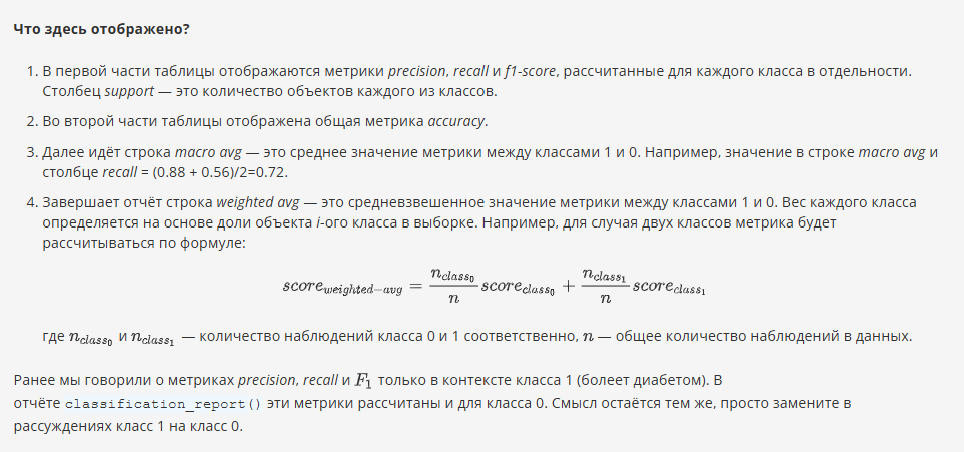

Представим ситуацию, что дополнительная диагностика диабета в нашей клинике довольно дорогая. Но при этом нам важно выявить диабет у как можно большего числа людей. То есть нам важен и precision, и recall.

При этом наш recall равен 0.56, то есть мы находим только 56 % больных диабетом пациентов среди всех болеющих диабетом. Согласитесь, не очень хороший показатель (чуть выше половины). Можем ли мы его как-то улучшить?

Давайте будем **изменять порог принятия решений**. По умолчанию в sklearn порог вероятности для моделей классификации составляет 0.5. То есть если вероятность наличия диабета у пациента выше 0.5, то модель относит его к больным диабетом, а если меньше 0.5 — к здоровым.

Но как будут меняться значения метрик recall, precision и $F_1$, если мы попробуем изменить порог вероятности, например на 0.4, 0.3 или 0.6? Давайте проследим за этим.

>Примечание. Геометрически регулировка порога вероятности для логистической регрессии означает движение разделяющей плоскости.

Сделаем предсказание вероятности наличия диабета моделью log_reg_full для каждого пациента из нашей выборки. Затем создадим несколько различных порогов вероятности в диапазоне от 0.1 до 1 с шагом 0.05. В цикле будем определять класс пациента при различных порогах вероятности. В конце рассчитаем метрики.

In [ ]:
#Считаем вероятности наличия диабета для каждого из пациентов
#Нас интересует только вероятность класса (второй столбец)
y_proba_pred = log_reg_full.predict_proba(diabetes_data.drop('Outcome', axis=1))[:, 1]
#Для удобства завернём numpy-массив в Pandas Series
y_proba_pred = pd.Series(y_proba_pred)
#Создадим списки, в которых будем хранить значения метрик 
recall_scores = []
precision_scores = []
f1_scores = []
#Сгенерируем набор вероятностных порогов в диапазоне от 0.1 до 1
thresholds = np.arange(0.1, 1, 0.05)
#В цикле будем перебирать сгенерированные пороги
for threshold in thresholds:
    #Пациентов, для которых вероятность наличия диабета > threshold, относим к классу 1
    #В противном случае — к классу 0
    y_pred = y_proba_pred.apply(lambda x: 1 if x>threshold else 0)
    #Считаем метрики и добавляем их в списки
    recall_scores.append(metrics.recall_score(y, y_pred))
    precision_scores.append(metrics.precision_score(y, y_pred))
    f1_scores.append(metrics.f1_score(y, y_pred))

Теперь у нас есть три списка (recall_scores, precision_scores и f1_scores), в которых хранятся значения метрик при различных значениях порога вероятности P.

Давайте построим графики зависимости метрик от порога вероятности:

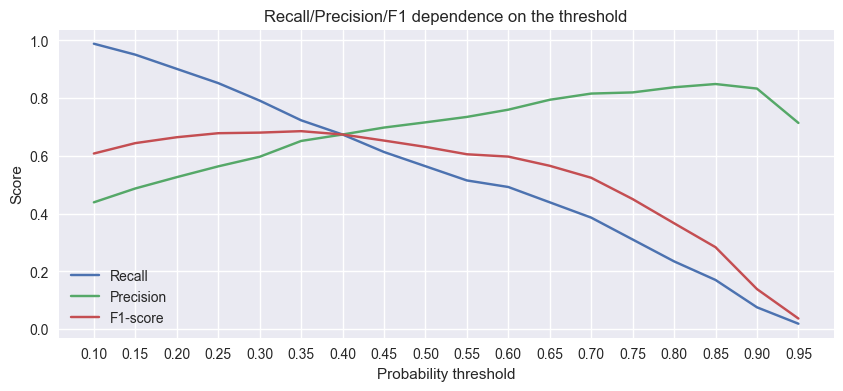

In [ ]:
#Визуализируем метрики при различных threshold
fig, ax = plt.subplots(figsize=(10, 4)) #фигура + координатная плоскость
#Строим линейный график зависимости recall от threshold
ax.plot(thresholds, recall_scores, label='Recall')
#Строим линейный график зависимости precision от threshold
ax.plot(thresholds, precision_scores, label='Precision')
#Строим линейный график зависимости F1 от threshold
ax.plot(thresholds, f1_scores, label='F1-score')
 
#Даём графику название и подписываем оси
ax.set_title('Recall/Precision/F1 dependence on the threshold')
ax.set_xlabel('Probability threshold')
ax.set_ylabel('Score')
#Устанавливаем отметки по оси x
ax.set_xticks(thresholds) 
#Отображаем легенду
ax.legend();

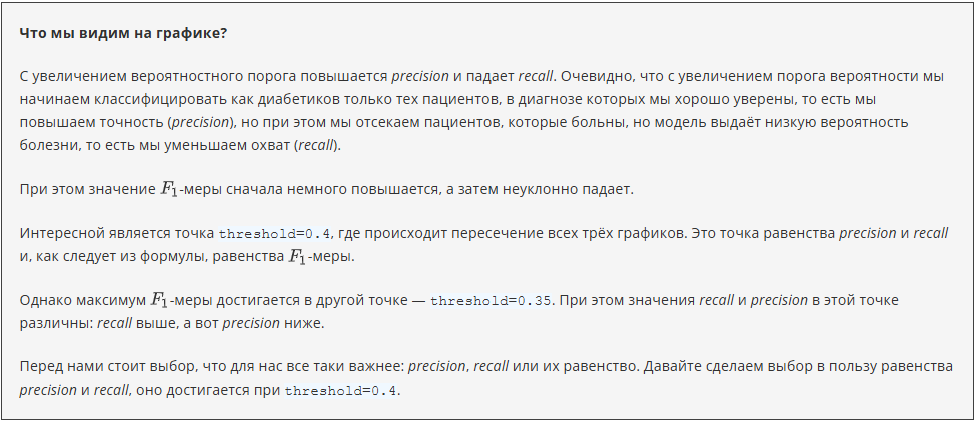

Как теперь мы можем сделать предсказание класса, обладая данной информацией?

Мы делаем предсказание вероятности наличия диабета для всех пациентов, а затем вручную определяем всех пациентов, у которых эта вероятность > 0.4, в класс 1, а остальных — в класс 0. Далее считаем метрики:

In [ ]:
#Задаём оптимальный порог вероятностей
threshold_opt = 0.4
#Пациентов, для которых вероятность наличия диабета > 0.4, относим к классу 1
#В противном случае — к классу 0
y_pred_opt = y_proba_pred.apply(lambda x: 1 if x > threshold_opt else 0)
#Считаем метрики
print(metrics.classification_report(y, y_pred_opt))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83       493
           1       0.67      0.67      0.67       264

    accuracy                           0.77       757
   macro avg       0.75      0.75      0.75       757
weighted avg       0.77      0.77      0.77       757



>Итак, мы смогли найти баланс между precision и recall, подобрав оптимальный порог вероятности.

Стоит отметить, что в DS-сообществе распространена практика подбора оптимального порога, так как он зависит от конкретных задач и значение 0.5 далеко не всегда является истинным.

## ДОСТОИНСТВА И НЕДОСТАТКИ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ

"+" 

* Простой, интерпретируемый, но в то же время эффективный алгоритм. Благодаря этому он очень популярен в мире машинного обучения.
* Поиск параметров линейный или квадратичный (в зависимости от метода оптимизации), то есть ресурсозатратность алгоритма очень низкая.
* Не требует подбора внешних параметров (гиперпараметров), так как практически не зависит от них.

"-" 

* Алгоритм работает хорошо, только когда классы линейно разделимы, что в реальных задачах бывает очень редко. Поэтому обычно данная модель используется в качестве baseline.


В завершение изучения логистической регрессии можно добавить, что недостаток с линейной разделимостью классов можно побороть с помощью введения полиномиальных признаков, тем самым снизив смещение модели. Тогда логистическая регрессия вместо разделяющей плоскости будет означать выгнутую разделяющую поверхность сложной структуры.

Однако мы знаем, что с этим трюком стоит быть аккуратным, так как можно получить переобученную модель. Поэтому в комбинации с полиномиальными признаками стоит подобрать наилучший параметр регуляризации.

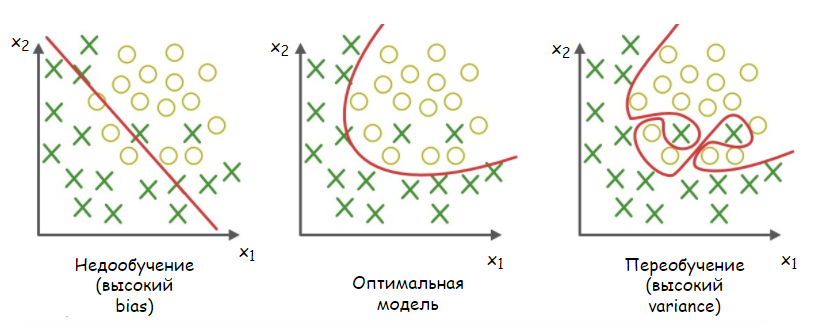

In [ ]:
y_true = [0, 0, 1, 1, 1, 1, 0, 1]
y_pred = [0, 1, 0, 0, 1, 1, 0, 1]
print(f'{metrics.precision_score(y_true, y_pred):.2f}')

0.75


In [ ]:
y_true = [0, 0, 1, 1, 1, 1, 0, 1]
y_pred = [0, 1, 0, 0, 1, 1, 0, 1]
print(f'{metrics.recall_score(y_true, y_pred):.2f}')


0.60


In [ ]:
y_true = [0, 0, 1, 1, 1, 1, 0, 1]
y_pred = [0, 1, 0, 0, 1, 1, 0, 1]
print(f'{metrics.f1_score(y_true, y_pred):.2f}')

0.67


---

# <center> Мультиклассовая классификация

Но что делать, когда классов, на которые необходимо разделить данные, больше 2? Например, классификация автомобилей по различным маркам или определение национальности по фотографии и т. д.

В таком случае используется очень простой подход, который называется **«один против всех» (one-vs-over)**.

>Идея этого подхода очень простая. Если у нас есть k различных классов (k>2), давайте обучим k классификаторов, каждый из которых будет предсказывать вероятности принадлежности каждого объекта к определённому классу.

Например, у нас есть три класса, обозначенные как 0, 1 и 2. Тогда мы обучаем три классификатора: первый из них учится отличать класс 0 от классов 1 и 2, второй — класс 1 от классов 0 и 2, а третий — класс 2 от классов 1 и 0. Таким образом, класс, на который «заточен» классификатор, мы обозначаем как 1, а остальные классы — как 0.

Когда каждая из трёх моделей сделает предсказание вероятностей для объекта, итоговый классификатор будет выдавать класс, который соответствует самой «уверенной» модели.

Схематично это можно представить следующим образом:

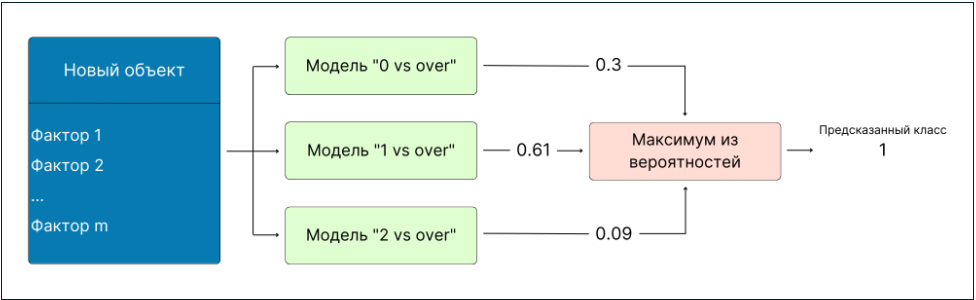

Если мы используем в качестве классификатора логистическую регрессию и количество факторов равно двум (x1 и x2), то можно изобразить тепловую карту вероятностей принадлежности к каждому из классов в каждой точке пространства, а также разделяющие плоскости, которые образуются при пороге вероятности в 0.5. 

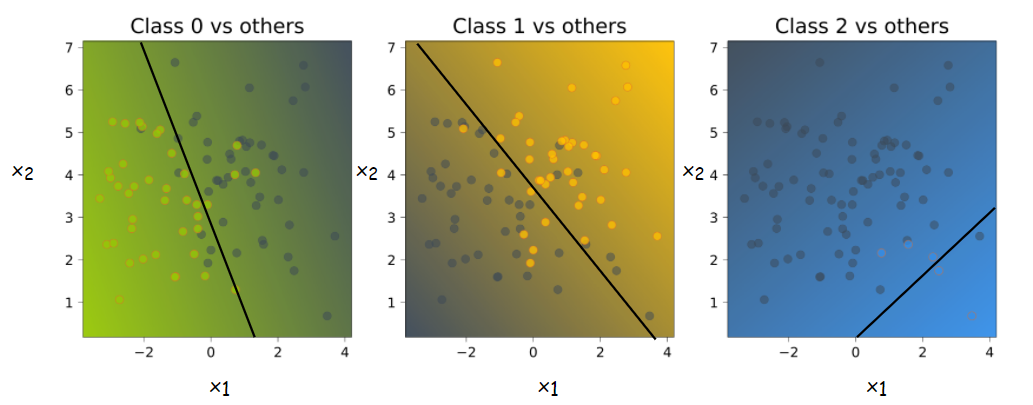

На тепловых картах каждый класс обозначен своим цветом: 0 — зелёным, 1 — жёлтым, 2 — синим. Чем ярче цвет, тем выше вероятность принадлежности к каждому к классу в этой области пространства.

В результате у нас получится три различных пространства вероятностей, что-то вроде трёх параллельных реальностей. Чтобы собрать всё это воедино, мы выбираем в каждой точке пространства максимум из вероятностей. Получим следующую картину:

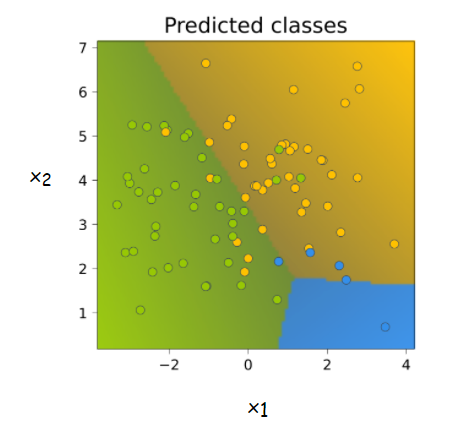

Модель логистической регрессии легко обобщается на случай мультиклассовой классификации. Пусть мы построили несколько разделяющих плоскостей с различными наборами параметров k, где k — номер классификатора. То есть имеем K разделяющих плоскостей:
$$z_k=w_{0k}+\sum_{j=1} ^m w_{jk}x_j=w_k \cdot x$$
Чтобы преобразовать результат каждой из построенных моделей в вероятности в логистической регрессии, используется функция softmax — многомерный аналог сигмоиды:
$$\hat{P}_k=softmax(z_k)=\frac{exp(\hat{y}_k)}{\sum_{k=1} ^{K} exp(\hat{y}_{jk})}$$

Данная функция выдаёт нормированные вероятности, то есть в сумме для всех классов вероятность будет равна 1.

---

## МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ НА PYTHON

In [ ]:
penguins_data = sns.load_dataset('penguins')
penguins_data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Описание данных:
* species — класс пингвина ('Adelie', 'Chinstrap', 'Gentoo'), **целевой признак**;
* island — остров, на котором живёт пингвин ('Torgersen', 'Biscoe', 'Dream');
* bill_length_mm — длина клюва в миллиметрах;
* bill_depth_mm — толщина клюва в миллиметрах;
* flipper_length_mm — длина крыльев;
* body_mass_g — масса;
* sex — пол ('Male', 'Female').

Наша цель — предсказать класс пингвина.

Очевидно, что классификация является мультиклассовой, так как возможных значений три.

Для начала давайте посмотрим на пропуски в данных:

In [ ]:
penguins_data.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Итак, в некоторых столбцах есть пропуски.

Логистическая регрессия — модель, которая не умеет работать с пропусками. Чтобы не получить ошибку, необходимо произвести предварительную предобработку. Для простоты давайте удалим все строки, содержащие пропуски в данных:

In [ ]:
penguins_data = penguins_data.dropna()

Теперь, когда пропусков в данных больше нет, разделим набор данных на матрицу наблюдений X и столбец с ответами y.

In [ ]:
X = penguins_data.drop('species', axis=1)
y = penguins_data['species']
X.head()

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Torgersen,39.3,20.6,190.0,3650.0,Male


Данные содержат строковые категориальные столбцы — island и sex. Логистическая регрессия не умеет работать со строковыми значениями. Необходимо произвести кодирование категориальных признаков. 

>Примечание. Кодировать целевую переменную y не нужно, даже если она представлена в виде строковых значений. Это не влияет на работу модели.

In [ ]:
X_dummies = pd.get_dummies(X)
X_dummies.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Biscoe,island_Dream,island_Torgersen,sex_Female,sex_Male
0,39.1,18.7,181.0,3750.0,False,False,True,False,True
1,39.5,17.4,186.0,3800.0,False,False,True,True,False
2,40.3,18.0,195.0,3250.0,False,False,True,True,False
4,36.7,19.3,193.0,3450.0,False,False,True,True,False
5,39.3,20.6,190.0,3650.0,False,False,True,False,True


Теперь данные готовы для подачи в модель.

Создаём модель логистической регрессии, значение параметра multi_class выставляем на 'multinomial' (мультиклассовая классификация), max_iter — на 1000 (для обеспечения сходимости), random_state=42.

Затем обучим модель с помощью метода fit() и сделаем предсказание вероятностей принадлежности к каждому из классов с помощью метода predict_proba() и самих классов — с помощью метода predict(). Вероятности округлим до второго знака после запятой.

In [ ]:
#Создаём объект класса LogisticRegression
log_reg = linear_model.LogisticRegression(
    multi_class='multinomial', #мультиклассовая классификация
    max_iter=1000, #количество итераций, выделенных на сходимость
    random_state=42 #генерация случайных чисел
)
 
#Обучаем модель 
log_reg.fit(X_dummies, y)
#Делаем предсказание вероятностей
y_pred_proba = np.round(log_reg.predict_proba(X_dummies), 2)
#Делаем предсказание класса
y_pred = log_reg.predict(X_dummies)

Для наглядности создадим таблицу из вероятностей для каждого класса и финального предсказания. Выберем пять случайных строк из этой таблицы с помощью метода [sample()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html):

In [ ]:
#Создаём DataFrame из вероятностей
y_pred_proba_df = pd.DataFrame(
    y_pred_proba, 
    columns=['Adelie', 'Chinstrap', 'Gentoo']
)
#Создаём DataFrame из предсказанных классов
y_pred_df = pd.DataFrame(
    y_pred, 
    columns=['Predicted Class']
)
#Объединяем таблицы по вертикальной оси
y_df = pd.concat([y_pred_proba_df, y_pred_df], axis=1)
#Выбираем пять случайных строк
y_df.sample(5, random_state=2)

,Adelie,Chinstrap,Gentoo,Predicted Class
277,0.00,0.00,1.0,Gentoo
223,0.00,0.00,1.0,Gentoo
7,0.78,0.22,0.0,Adelie
160,0.00,1.00,0.0,Chinstrap
65,1.00,0.00,0.0,Adelie


Из таблицы можно проследить, как происходит предсказание класса пингвина на основе полученных вероятностей. Видно, что выбирается класс, вероятность принадлежности к которому максимальна.

Например, для строки под номером 7 логистическая регрессия предсказала три вероятности: 0.79 — вероятность принадлежности к классу Adelie, 0.21 — к классу Chinstrap и 0 — к классу Gentoo. На основе этих вероятностей было сделано предсказание и модель отнесла пингвина в строке 7 к классу Adelie.

Вот так и происходит мультиклассовая классификация. 

Давайте посмотрим, как в таком случае будет выглядеть отчёт о метриках:

In [ ]:
print(metrics.classification_report(y, y_pred))

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00       146
   Chinstrap       1.00      1.00      1.00        68
      Gentoo       1.00      1.00      1.00       119

    accuracy                           1.00       333
   macro avg       1.00      1.00      1.00       333
weighted avg       1.00      1.00      1.00       333



Для мультиклассовой классификации к отчёту просто добавляется новая строка, соответствующая третьему классу. 

Из отчёта видно, что наша модель идеально решила задачу классификации (все метрики равны 1), то есть классы оказались линейно разделимыми.